# Conditional normalizing flow for SFR surface density

Fits a conditional neural spline flow on all galaxies combined, learning the
full conditional distribution:

$$p(\log\Sigma_{\rm SFR} \mid \mathbf{x})$$

via a stack of rational-quadratic spline transforms conditioned on the 5 context features.
Then shows predictions per galaxy on the KS relation and compares R² and NLL to the KS98 baseline.

In [1]:
import sys
from pathlib import Path

# Ensure project root is on the path (for notebook kernels)
project_root = str(Path.cwd().parents[1]) if Path.cwd().name == "normflow" else str(Path.cwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

from sfemulator.normflow.model import train_flow, predict_mean, predict_nll, sample

# Unit conversions from CGS
PC_TO_CM = 3.086e18
KPC_TO_CM = 3.086e21
MSOL_TO_G = 1.99e33
YR_TO_S = 3.15576e7

SURFDENS_TO_MSUN_PC2 = PC_TO_CM**2 / MSOL_TO_G
SFR_SURFDENS_TO_MSUN_YR_KPC2 = YR_TO_S * KPC_TO_CM**2 / MSOL_TO_G

CONTEXT_NAMES = ["gas_surfdens", "star_surfdens", "rotcurve", "kappa", "dm_voldens"]

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")

Device: mps


In [2]:
SNAP_DIR = Path("../../snapshots")

galaxies = {
    "NGC300":   {"dir": "NGC300",   "pixel_pc": 80.0},
    "ETG-vlM":  {"dir": "ETG-vlM",  "pixel_pc": 80.0},
    "ETG-lowM": {"dir": "ETG-lowM", "pixel_pc": 80.0},
    "ETG-medM": {"dir": "ETG-medM", "pixel_pc": 80.0},
    "ETG-hiM":  {"dir": "ETG-hiM",  "pixel_pc": 80.0},
}

def load_galaxy(name, info):
    """Load all snapshots for one galaxy, return per-pixel context and SFR surface density."""
    snap_files = sorted((SNAP_DIR / info["dir"]).glob("sfr_context_*.npz"))
    pixel_area = (info["pixel_pc"] * PC_TO_CM) ** 2

    all_context = []
    all_sfr_surfdens = []

    for f in snap_files:
        d = np.load(f)
        context, sfr, pixel_id = d["context"], d["sfr"], d["pixel_id"]
        n_pixels = context.shape[0]

        sfr_sum = np.zeros(n_pixels)
        np.add.at(sfr_sum, pixel_id, sfr)
        sfr_surfdens = sfr_sum / pixel_area

        has_sf = sfr_surfdens > 0
        all_context.append(context[has_sf])
        all_sfr_surfdens.append(sfr_surfdens[has_sf])

    ctx = np.concatenate(all_context)
    sfr_sd = np.concatenate(all_sfr_surfdens)
    print(f"{name}: {len(snap_files)} snapshots, {len(sfr_sd)} star-forming pixels")
    return ctx, sfr_sd

data = {name: load_galaxy(name, info) for name, info in galaxies.items()}

NGC300: 31 snapshots, 40556 star-forming pixels
ETG-vlM: 31 snapshots, 12532 star-forming pixels


ETG-lowM: 31 snapshots, 28816 star-forming pixels
ETG-medM: 30 snapshots, 19053 star-forming pixels


ETG-hiM: 22 snapshots, 31052 star-forming pixels


In [3]:
# Combine all galaxies, work in log-space, filter non-finite
all_ctx = np.concatenate([ctx for ctx, _ in data.values()])
all_sfr = np.concatenate([sfr for _, sfr in data.values()])

log_ctx = np.log10(all_ctx)
log_sfr = np.log10(all_sfr)
finite = np.all(np.isfinite(log_ctx), axis=1) & np.isfinite(log_sfr)

X_raw = log_ctx[finite]
y_raw = log_sfr[finite]
print(f"Training samples: {len(y_raw)} ({finite.sum() / len(finite) * 100:.1f}% of total)")

# Standardize inputs and target (flow works best with standardized y too)
x_scaler = StandardScaler().fit(X_raw)
y_scaler = StandardScaler().fit(y_raw.reshape(-1, 1))
X_scaled = x_scaler.transform(X_raw).astype(np.float32)
y_scaled = y_scaler.transform(y_raw.reshape(-1, 1)).ravel().astype(np.float32)
print(f"y range after scaling: [{y_scaled.min():.2f}, {y_scaled.max():.2f}]")

Training samples: 130715 (99.0% of total)
y range after scaling: [-86.40, 2.17]


/var/folders/30/hdkspf4j307b3qg9j5yb_cgm0000gp/T/ipykernel_22169/2044698456.py:5: RuntimeWarning: divide by zero encountered in log10
  log_ctx = np.log10(all_ctx)
/var/folders/30/hdkspf4j307b3qg9j5yb_cgm0000gp/T/ipykernel_22169/2044698456.py:5: RuntimeWarning: invalid value encountered in log10
  log_ctx = np.log10(all_ctx)


  Epoch   50/50  NLL = 0.6806


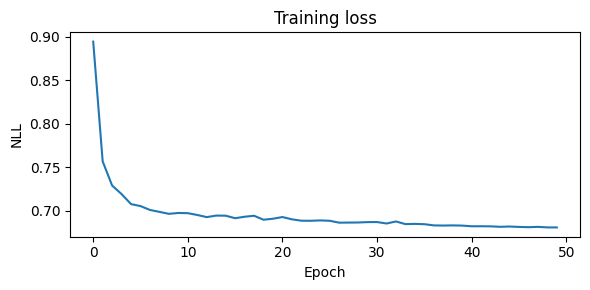

In [4]:
# Train flow
model, losses = train_flow(
    X_scaled, y_scaled,
    n_layers=8,
    n_hidden=64,
    n_bins=16,
    tail_bound=5.0,
    lr=1e-3,
    n_epochs=50,
    batch_size=2048,
    device=device,
)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(losses)
ax.set_xlabel("Epoch")
ax.set_ylabel("NLL")
ax.set_title("Training loss")
plt.tight_layout()
plt.show()

In [5]:
# Helper: convert flow predictions (standardized) back to CGS log-space
y_mean = y_scaler.mean_[0]
y_std = y_scaler.scale_[0]

def to_phys(log_sfr_scaled):
    """Standardized log-space -> physical units (Msun/yr/kpc^2) log-space."""
    return log_sfr_scaled * y_std + y_mean + np.log10(SFR_SURFDENS_TO_MSUN_YR_KPC2)

def prep_galaxy(ctx):
    """Prepare galaxy context for the flow: log, filter, scale, tensorize."""
    log_ctx = np.log10(ctx)
    finite_gal = np.all(np.isfinite(log_ctx), axis=1)
    X_gal = x_scaler.transform(log_ctx[finite_gal]).astype(np.float32)
    X_gal_t = torch.tensor(X_gal).to(device)
    return finite_gal, X_gal_t

/var/folders/30/hdkspf4j307b3qg9j5yb_cgm0000gp/T/ipykernel_22169/1002505421.py:11: RuntimeWarning: divide by zero encountered in log10
  log_ctx = np.log10(ctx)
/var/folders/30/hdkspf4j307b3qg9j5yb_cgm0000gp/T/ipykernel_22169/1002505421.py:11: RuntimeWarning: invalid value encountered in log10
  log_ctx = np.log10(ctx)


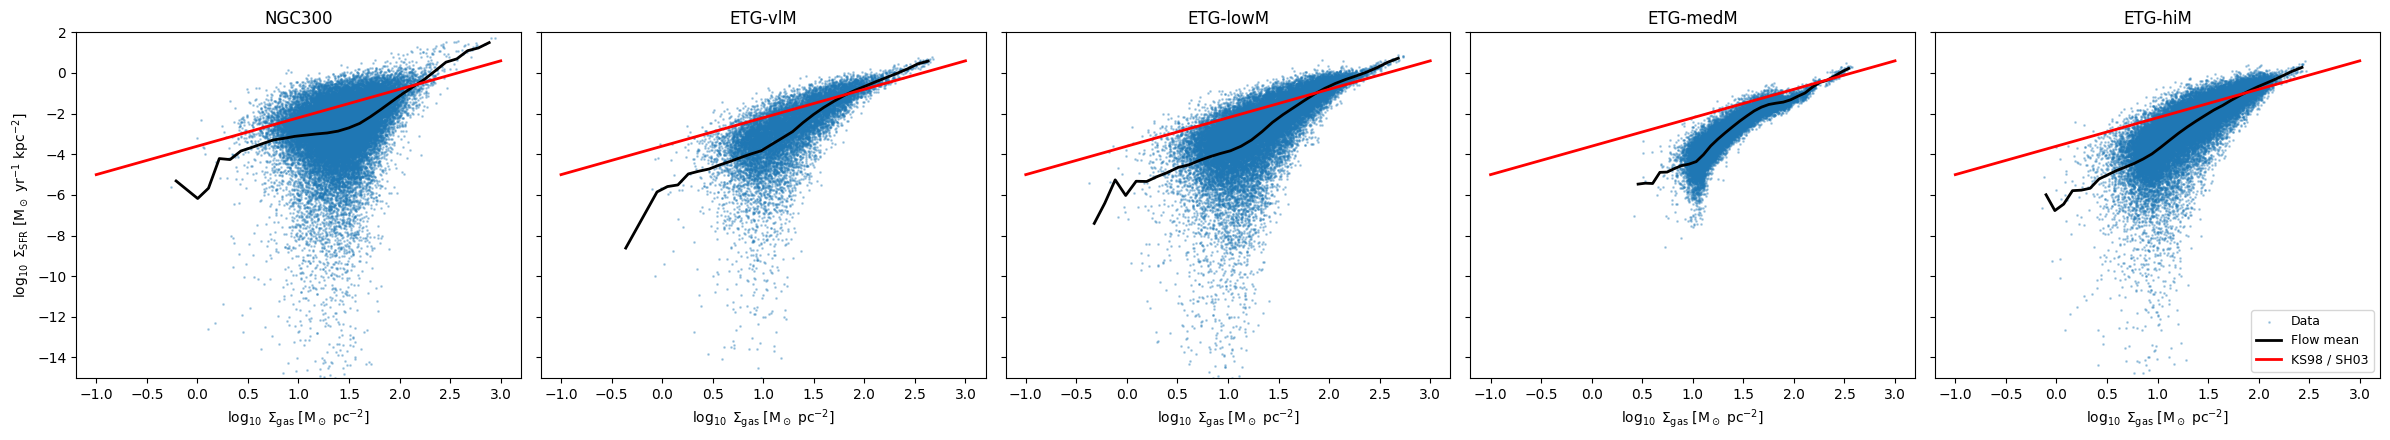

In [6]:
# KS98 line
sig_gas_ks = np.logspace(-1, 3, 200)
sig_sfr_ks = 2.5e-4 * sig_gas_ks**1.4

fig, axes = plt.subplots(1, 5, figsize=(24, 4.5), sharey=True)

for ax, (name, (ctx, sfr_sd)) in zip(axes, data.items()):
    log_gas = np.log10(ctx[:, 0] * SURFDENS_TO_MSUN_PC2)
    log_sfr_actual = np.log10(sfr_sd * SFR_SURFDENS_TO_MSUN_YR_KPC2)

    # Predict flow mean
    finite_gal, X_gal_t = prep_galaxy(ctx)
    log_sfr_pred_scaled = predict_mean(model, X_gal_t)
    log_sfr_pred_phys = to_phys(log_sfr_pred_scaled)

    # Scatter of actual data
    ax.scatter(log_gas, log_sfr_actual, s=1, alpha=0.3, label="Data")

    # Binned mean of flow predictions
    log_gas_v = log_gas[finite_gal]
    bin_edges = np.linspace(log_gas_v.min(), log_gas_v.max(), 31)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    bin_means = np.full(30, np.nan)
    for i in range(30):
        in_bin = (log_gas_v >= bin_edges[i]) & (log_gas_v < bin_edges[i + 1])
        if in_bin.sum() > 0:
            bin_means[i] = np.mean(log_sfr_pred_phys[in_bin])
    ok = np.isfinite(bin_means)
    ax.plot(bin_centers[ok], bin_means[ok], "k-", lw=2, label="Flow mean")

    # KS98 line
    ax.plot(np.log10(sig_gas_ks), np.log10(sig_sfr_ks), "r-", lw=2, label="KS98 / SH03")

    ax.set_title(name)
    ax.set_xlabel(r"$\log_{10}\;\Sigma_{\rm gas}$ [M$_\odot$ pc$^{-2}$]")

axes[0].set_ylim([-15., 2.])
axes[0].set_ylabel(r"$\log_{10}\;\Sigma_{\rm SFR}$ [M$_\odot$ yr$^{-1}$ kpc$^{-2}$]")
axes[-1].legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

/var/folders/30/hdkspf4j307b3qg9j5yb_cgm0000gp/T/ipykernel_22169/1002505421.py:11: RuntimeWarning: divide by zero encountered in log10
  log_ctx = np.log10(ctx)
/var/folders/30/hdkspf4j307b3qg9j5yb_cgm0000gp/T/ipykernel_22169/1002505421.py:11: RuntimeWarning: invalid value encountered in log10
  log_ctx = np.log10(ctx)


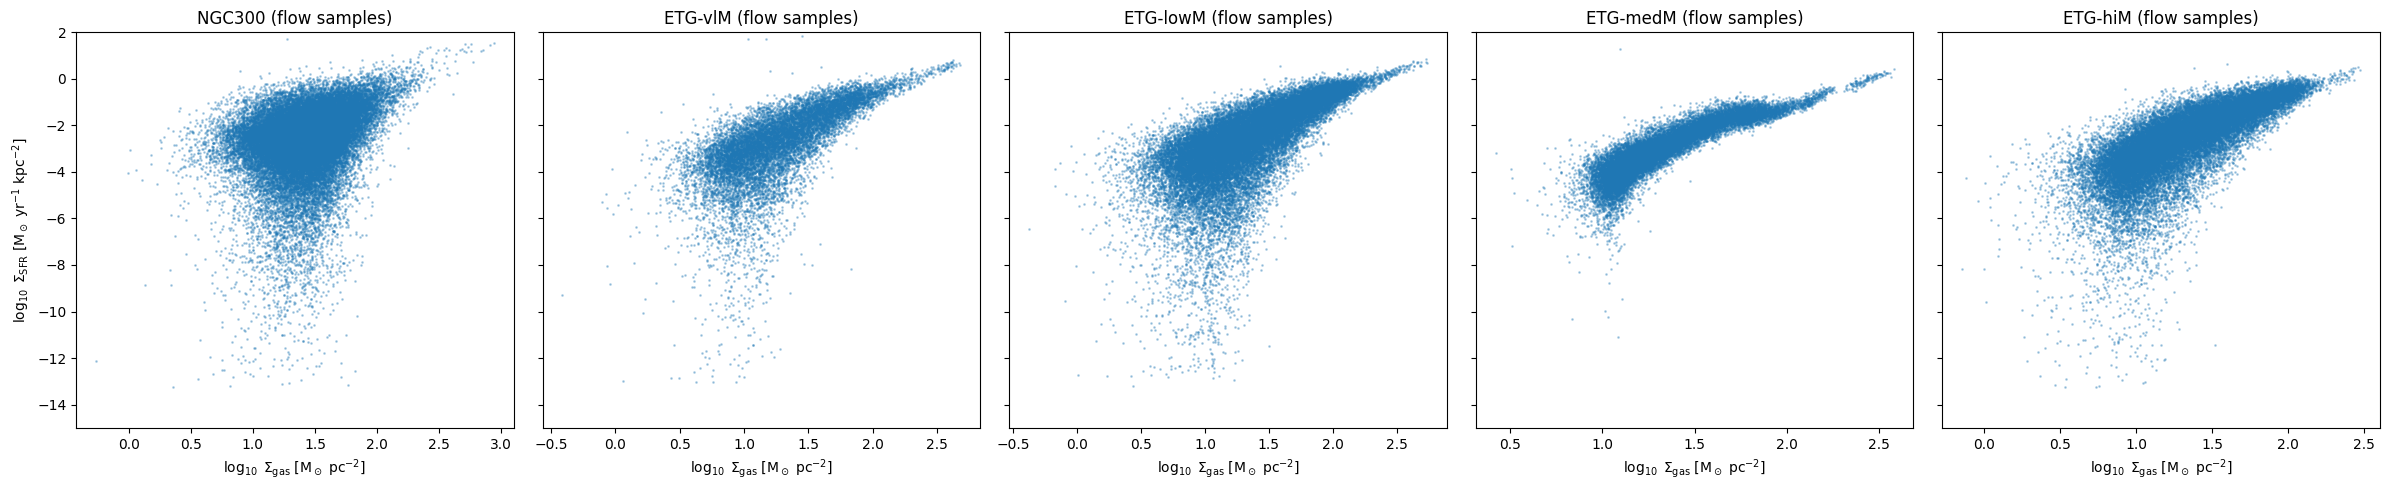

In [7]:
# Sampled KS relation: draw one SFR sample per pixel from the flow
sig_gas_ks = np.logspace(-1, 3, 200)
sig_sfr_ks = 2.5e-4 * sig_gas_ks**1.4

fig, axes = plt.subplots(1, 5, figsize=(24, 5), sharey=True, sharex="col")

for col, (name, (ctx, sfr_sd)) in enumerate(data.items()):
    log_gas = np.log10(ctx[:, 0] * SURFDENS_TO_MSUN_PC2)

    # Sample from flow
    finite_gal, X_gal_t = prep_galaxy(ctx)
    log_sfr_sampled = to_phys(sample(model, X_gal_t))
    log_gas_v = log_gas[finite_gal]

    axes[col].scatter(log_gas_v, log_sfr_sampled, s=1, alpha=0.3)
    axes[col].set_ylim([-15., 2.])
    axes[col].set_title(f"{name} (flow samples)")
    axes[col].set_xlabel(r"$\log_{10}\;\Sigma_{\rm gas}$ [M$_\odot$ pc$^{-2}$]")

axes[0].set_ylabel(r"$\log_{10}\;\Sigma_{\rm SFR}$ [M$_\odot$ yr$^{-1}$ kpc$^{-2}$]")

plt.tight_layout()
plt.show()

In [8]:
# R² per galaxy: flow vs KS98
print(f"{'Galaxy':<12} {'R² (Flow)':>12} {'R² (KS98)':>12}")
print("-" * 38)

for name, (ctx, sfr_sd) in data.items():
    log_sfr_actual = np.log10(sfr_sd)
    finite_gal, X_gal_t = prep_galaxy(ctx)

    # Flow R² (predict in standardized space, unstandardize to CGS log)
    y_pred_scaled = predict_mean(model, X_gal_t)
    y_pred_cgs = y_pred_scaled * y_std + y_mean
    r2_flow = r2_score(log_sfr_actual[finite_gal], y_pred_cgs)

    # KS98 R²
    log_gas_msun = np.log10(ctx[finite_gal, 0] * SURFDENS_TO_MSUN_PC2)
    y_pred_ks = np.log10(2.5e-4) + 1.4 * log_gas_msun - np.log10(SFR_SURFDENS_TO_MSUN_YR_KPC2)
    r2_ks = r2_score(log_sfr_actual[finite_gal], y_pred_ks)

    print(f"{name:<12} {r2_flow:>12.4f} {r2_ks:>12.4f}")

Galaxy          R² (Flow)    R² (KS98)
--------------------------------------


/var/folders/30/hdkspf4j307b3qg9j5yb_cgm0000gp/T/ipykernel_22169/1002505421.py:11: RuntimeWarning: divide by zero encountered in log10
  log_ctx = np.log10(ctx)
/var/folders/30/hdkspf4j307b3qg9j5yb_cgm0000gp/T/ipykernel_22169/1002505421.py:11: RuntimeWarning: invalid value encountered in log10
  log_ctx = np.log10(ctx)


NGC300             0.0615      -0.1681


ETG-vlM            0.4451      -0.0102


ETG-lowM           0.3405      -0.0084


ETG-medM           0.8277      -0.7564


ETG-hiM            0.4899       0.0109


In [9]:
# NLL per galaxy: flow (exact) vs KS98 (Gaussian with global variance)
log_gas_all_msun = np.log10(all_ctx[finite, 0] * SURFDENS_TO_MSUN_PC2)
ks_pred_all = np.log10(2.5e-4) + 1.4 * log_gas_all_msun - np.log10(SFR_SURFDENS_TO_MSUN_YR_KPC2)
ks_var = np.var(y_raw - ks_pred_all)

print(f"{'Galaxy':<12} {'NLL (Flow)':>12} {'NLL (KS98)':>12}")
print("-" * 38)

for name, (ctx, sfr_sd) in data.items():
    log_sfr_actual = np.log10(sfr_sd)
    finite_gal, X_gal_t = prep_galaxy(ctx)
    y_true = log_sfr_actual[finite_gal]

    # Flow NLL (in standardized space, then adjust for the Jacobian of standardization)
    y_true_scaled = ((y_true - y_mean) / y_std).astype(np.float32)
    y_true_t = torch.tensor(y_true_scaled).to(device)
    nll_flow_scaled = predict_nll(model, X_gal_t, y_true_t)
    # Adjust: log p(y) = log p(y_scaled) - log(y_std)
    nll_flow = nll_flow_scaled + np.log(y_std)

    # KS98 NLL (Gaussian)
    log_gas_msun = np.log10(ctx[finite_gal, 0] * SURFDENS_TO_MSUN_PC2)
    y_pred_ks = np.log10(2.5e-4) + 1.4 * log_gas_msun - np.log10(SFR_SURFDENS_TO_MSUN_YR_KPC2)
    nll_ks = 0.5 * np.log(2 * np.pi * ks_var) + 0.5 * np.mean((y_true - y_pred_ks)**2) / ks_var

    print(f"{name:<12} {nll_flow:>12.4f} {nll_ks:>12.4f}")

Galaxy         NLL (Flow)   NLL (KS98)
--------------------------------------
NGC300             1.9296       2.5113


/var/folders/30/hdkspf4j307b3qg9j5yb_cgm0000gp/T/ipykernel_22169/1002505421.py:11: RuntimeWarning: divide by zero encountered in log10
  log_ctx = np.log10(ctx)
/var/folders/30/hdkspf4j307b3qg9j5yb_cgm0000gp/T/ipykernel_22169/1002505421.py:11: RuntimeWarning: invalid value encountered in log10
  log_ctx = np.log10(ctx)


ETG-vlM            1.3215       2.0703
ETG-lowM           1.5839       2.3863


ETG-medM           0.4913       1.8830
ETG-hiM            1.2321       1.9996
